In [71]:
import sys
import scipy
import numpy
import matplotlib
import pandas
import sklearn
import seaborn



In [92]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [73]:
# Load dataset from Internet
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
names = ['id', 'clump_thickness', 'uniform_cell_size', 'uniform_cell_shape',
         'marginal_adhesion', 'single_epithelial_size', 'bare_nuclei',
         'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']
df = pd.read_csv(url,names=names)

In [74]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id                        0
clump_thickness           0
uniform_cell_size         0
uniform_cell_shape        0
marginal_adhesion         0
single_epithelial_size    0
bare_nuclei               0
bland_chromatin           0
normal_nucleoli           0
mitoses                   0
class                     0
dtype: int64


In [75]:
print("\nCount of '?' in each column:")
for column in df.columns:
    question_marks = (df[column] == '?').sum()
    if question_marks > 0:
        print(f"{column}: {question_marks}")


Count of '?' in each column:
bare_nuclei: 16


In [76]:
print(df['bare_nuclei'].dtype)

object


In [77]:
print("\nMethod 3 - Complete dataframe info:")
df.info()


Method 3 - Complete dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      699 non-null    int64 
 1   clump_thickness         699 non-null    int64 
 2   uniform_cell_size       699 non-null    int64 
 3   uniform_cell_shape      699 non-null    int64 
 4   marginal_adhesion       699 non-null    int64 
 5   single_epithelial_size  699 non-null    int64 
 6   bare_nuclei             699 non-null    object
 7   bland_chromatin         699 non-null    int64 
 8   normal_nucleoli         699 non-null    int64 
 9   mitoses                 699 non-null    int64 
 10  class                   699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [78]:
print(type(df['bare_nuclei'].iloc[0]))

<class 'str'>


In [79]:
print(df['bare_nuclei'].unique())

['1' '10' '2' '4' '3' '9' '7' '?' '5' '8' '6']


In [80]:
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'].replace('?', np.nan))

In [81]:
bare_nuclei_mean = df['bare_nuclei'].mean()

In [82]:
df['bare_nuclei'] = df['bare_nuclei'].fillna(bare_nuclei_mean)

In [83]:
print("\nNumber of missing values:")
print(df['bare_nuclei'].isnull().sum())


Number of missing values:
0


In [84]:
df.drop(['id'], axis=1, inplace=True)


In [85]:
# Describe the dataset
print(df.describe())

       clump_thickness  uniform_cell_size  uniform_cell_shape  \
count       699.000000         699.000000          699.000000   
mean          4.417740           3.134478            3.207439   
std           2.815741           3.051459            2.971913   
min           1.000000           1.000000            1.000000   
25%           2.000000           1.000000            1.000000   
50%           4.000000           1.000000            1.000000   
75%           6.000000           5.000000            5.000000   
max          10.000000          10.000000           10.000000   

       marginal_adhesion  single_epithelial_size  bare_nuclei  \
count         699.000000              699.000000   699.000000   
mean            2.806867                3.216023     3.544656   
std             2.855379                2.214300     3.601852   
min             1.000000                1.000000     1.000000   
25%             1.000000                2.000000     1.000000   
50%             1.000000

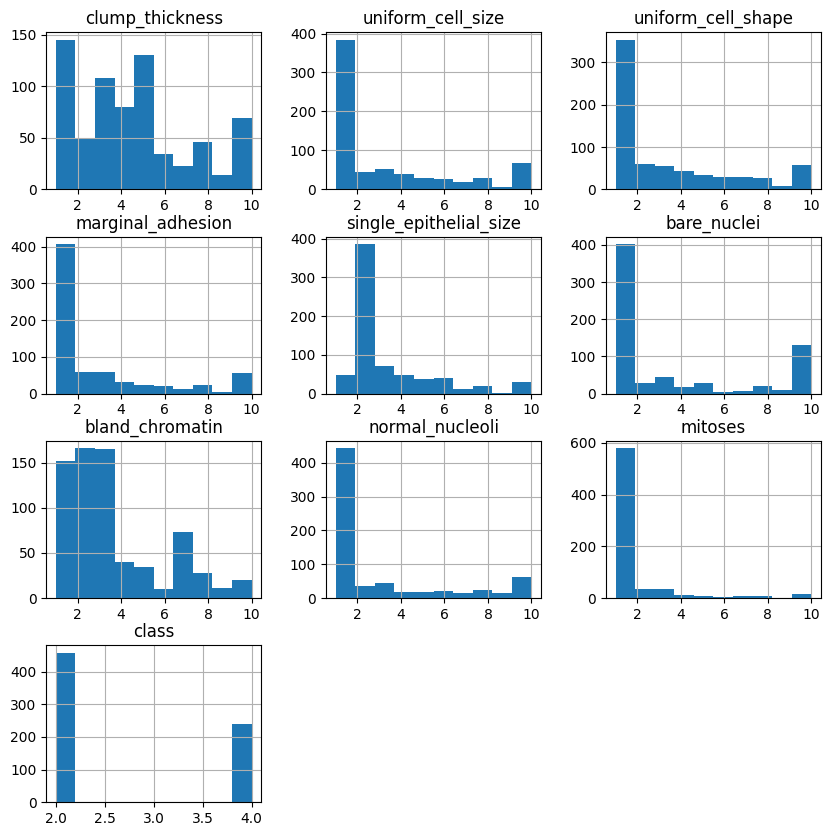

In [86]:
# Plot histograms for each variable
df.hist(figsize = (10,10))
plt.show()

In [87]:
print(df.describe())

       clump_thickness  uniform_cell_size  uniform_cell_shape  \
count       699.000000         699.000000          699.000000   
mean          4.417740           3.134478            3.207439   
std           2.815741           3.051459            2.971913   
min           1.000000           1.000000            1.000000   
25%           2.000000           1.000000            1.000000   
50%           4.000000           1.000000            1.000000   
75%           6.000000           5.000000            5.000000   
max          10.000000          10.000000           10.000000   

       marginal_adhesion  single_epithelial_size  bare_nuclei  \
count         699.000000              699.000000   699.000000   
mean            2.806867                3.216023     3.544656   
std             2.855379                2.214300     3.601852   
min             1.000000                1.000000     1.000000   
25%             1.000000                2.000000     1.000000   
50%             1.000000

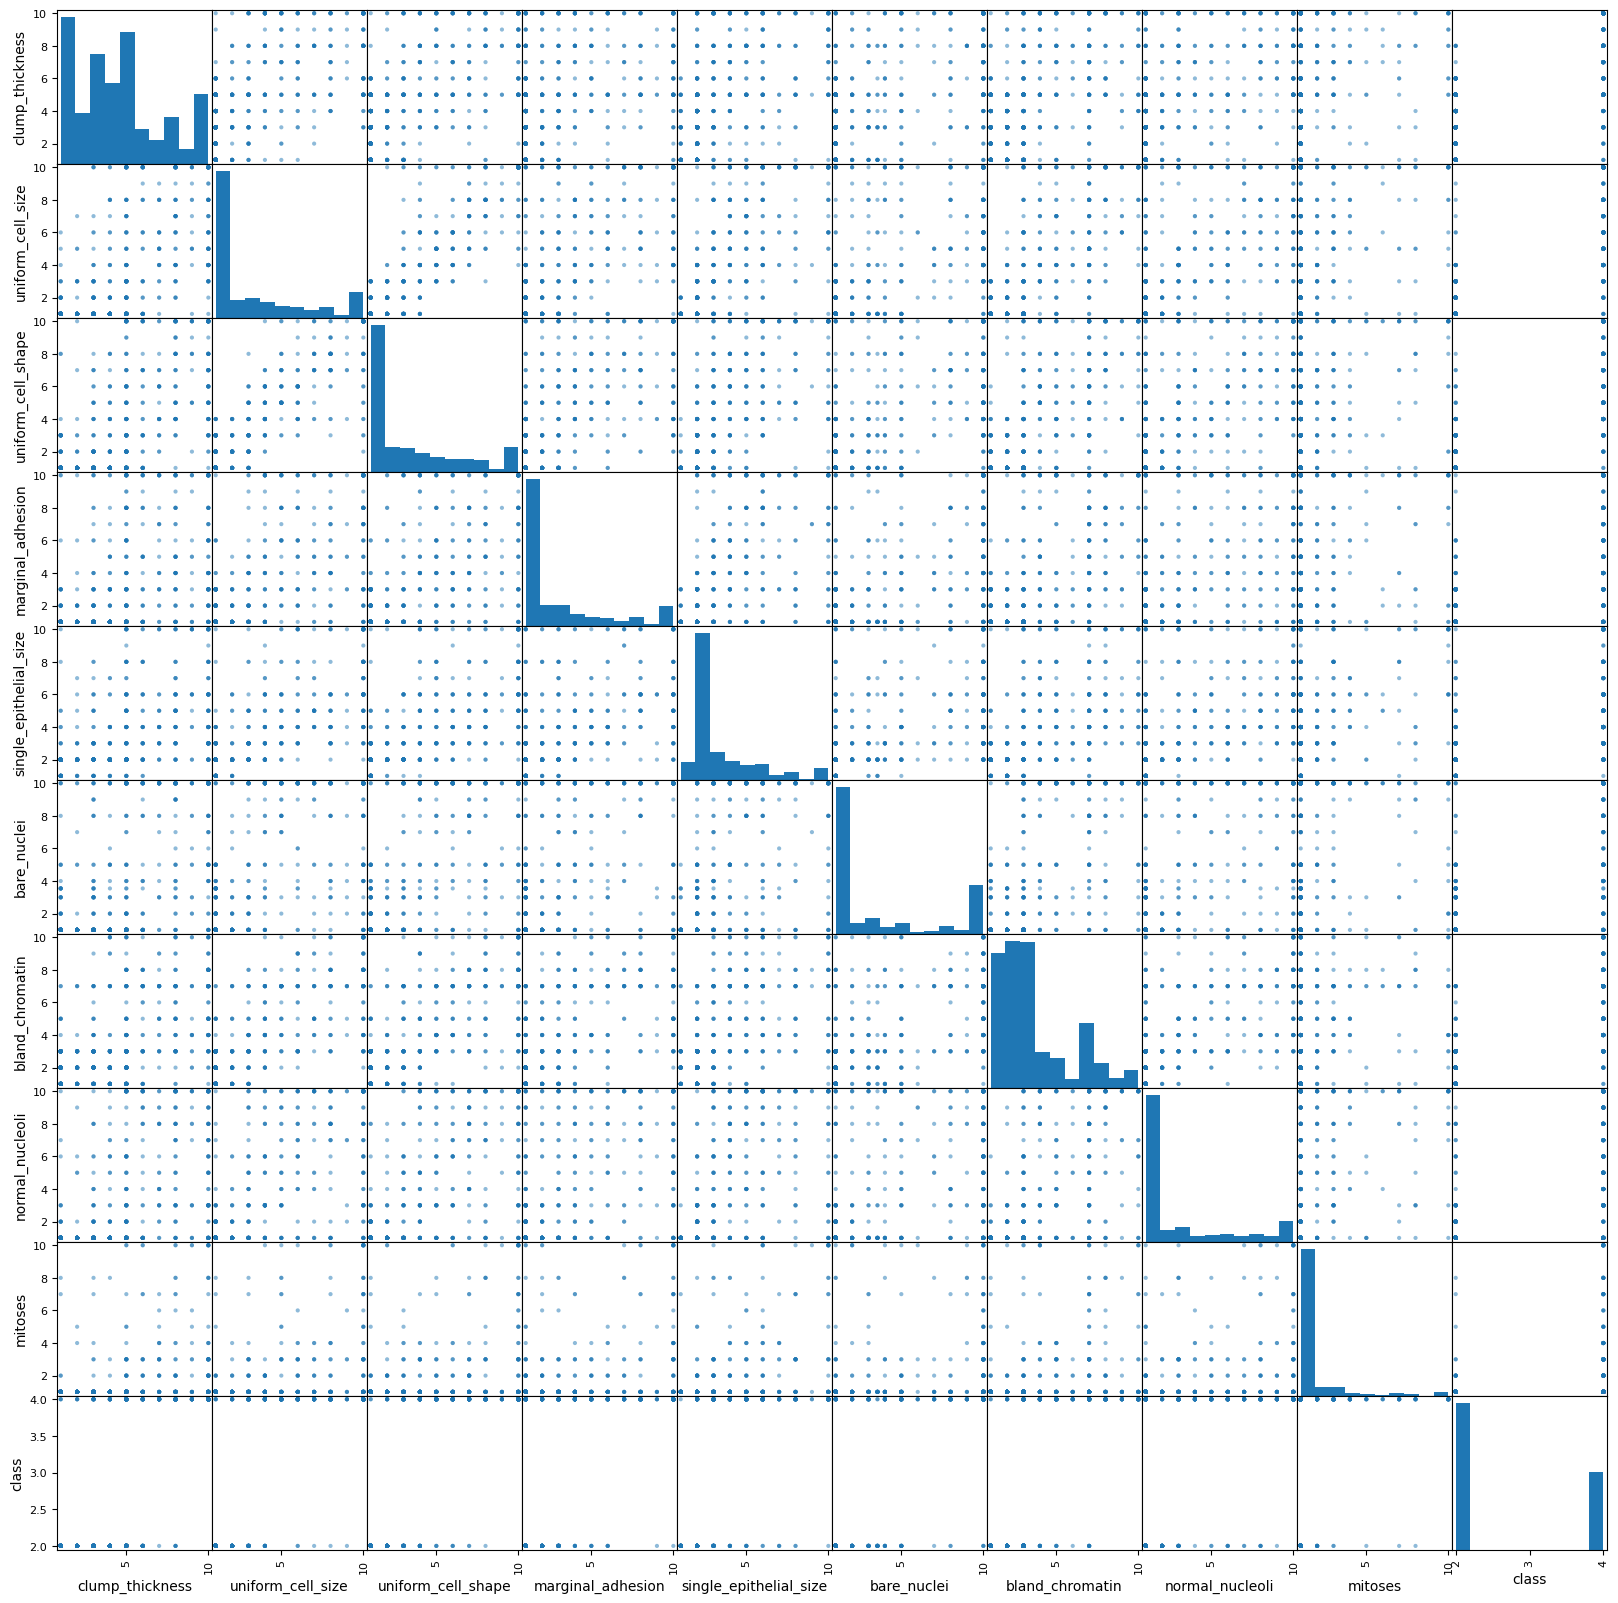

In [88]:
scatter_matrix(df, figsize=(20,20))
plt.show()

After carefully examining the scatter plot matrix and considering the patterns in the data. I would recommend using a more complex model rather than a linear classifier to best fit this data

**Clump Thickness** : measures the uniformity of cell clumps, with higher values indicating more irregular clumping, which can be indicative of malignancy.

**Uniformity of Cell Size** : It quantifies the variation in size among cells greater uniformity suggests benign characteristics while variability may point to malignancy.

**Uniformity of Cell Shape** :assesses the consistency in shape across cells

**Marginal Adhesion** : It evaluates how well cells stick to each other at the edges, increased adhesion is  associated with cancerous growths.

**Single Epithelial Cell Size** :  measures the size of individual epithelial cells, larger sizes are often linked to malignant conditions.

**Bare Nuclei** : indicates the presence of nuclei that are not surrounded by cytoplasm, a characteristic more common in malignant cells.

**Bland Chromatin** : This feature describes the texture of chromatin within the nucleus; blandness typically signifies benign tumors.

**Normal Nucleoli** : It assesses the normalcy of nucleoli (structures within the nucleus); abnormal nucleoli are often found in cancerous cells.

**Mitoses** : This counts the number of dividing cells; a higher mitotic rate is usually indicative of rapid cell division seen in malignant tumors.

**Class** : This is the target variable that categorizes samples as either benign (2) or malignant (4).

In [89]:
# Split the data into training (70%), validation (10%), and test (20%) sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 20% test set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42)  # 10% validation set from remaining 80%

In [90]:
# Define models to train
models = []
models.append(('KNN', KNeighborsClassifier(n_neighbors=5)))
models.append(('SVM', SVC()))

In [93]:
# Evaluate both models
results = []
names = []

for name, model in models:
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the validation set
    val_predictions = model.predict(X_val)

    # Calculate evaluation metrics for validation set
    val_accuracy = accuracy_score(y_val, val_predictions)
    val_precision = precision_score(y_val, val_predictions, average='weighted')
    val_recall = recall_score(y_val, val_predictions, average='weighted')
    val_f1 = f1_score(y_val, val_predictions, average='weighted')

    # Print the results for validation set
    print(f"Model: {name} (Validation Set)")
    print(f"Accuracy: {val_accuracy:.4f}")
    print(f"Precision: {val_precision:.4f}")
    print(f"Recall: {val_recall:.4f}")
    print(f"F1 Score: {val_f1:.4f}")
    print("\n")

    # Make predictions on the test set
    test_predictions = model.predict(X_test)

    # Calculate evaluation metrics for test set
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions, average='weighted')
    test_recall = recall_score(y_test, test_predictions, average='weighted')
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    # Print the results for test set
    print(f"Model: {name} (Test Set)")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print("\n")

Model: KNN (Validation Set)
Accuracy: 0.9571
Precision: 0.9570
Recall: 0.9571
F1 Score: 0.9569


Model: KNN (Test Set)
Accuracy: 0.9857
Precision: 0.9857
Recall: 0.9857
F1 Score: 0.9857


Model: SVM (Validation Set)
Accuracy: 0.9714
Precision: 0.9714
Recall: 0.9714
F1 Score: 0.9714


Model: SVM (Test Set)
Accuracy: 0.9714
Precision: 0.9715
Recall: 0.9714
F1 Score: 0.9713


